# The affine-anchor test, replicated across a G10 panel

The US result — the anchor-model term premium as the only predictor with positive realized
out-of-sample $R^2$ (Clark–West 10% star) — is one country, one sample. This notebook asks
the only question that can still change the result's **category**: does the *same,
pre-specified* pipeline replicate across ten developed markets?

**Why this is clean evidence and not another formulation.** Nothing is re-tuned: the anchor
($r^*$ proxy + CPI-trend $\pi_e$, same half-lives), the HW gap-regression $\kappa$, the
pure-expectations Vasicek curve, the TP construction, expanding windows, Newey–West, OOS
$R^2$, Clark–West — all identical to the US notebook. Running a fixed recipe on new data is
**replication**, the opposite of data mining: every additional country is independent
evidence, with **no multiple-testing discount**.

**Data (FRED/OECD MEI, per-series robust — a missing ticker drops only that country):**
10y government yields (`IRLTLT01*`), 3m interbank rates (`IR3TIB01*`), CPI
(`*CPIALLMINMEI`, quarterly fallback for AUS/NZL). One honest approximation is forced by
data: without full foreign curves, the 12m bond excess return uses the standard
**duration approximation** on the 10y level, $rx \approx y_{10} - D(y)\,\Delta y_{10} - r_{3m}$
— cruder than the US per-tenor construction, stated up front.

**How to read the verdict:** the *sign-replication count* (how many of 10 betas are
positive), the NW-t and OOS-$R^2$ counts, and the **mean-group t** (average beta over its
cross-country dispersion). Replication in most countries upgrades the US 10%-star to
cross-country evidence; failure to replicate is equally informative and gets reported
straight.

In [1]:
# ===== Data layer: FRED (pandas_datareader + direct-CSV fallback) =====
import numpy as np, pandas as pd, warnings
import matplotlib.pyplot as plt
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
plt.rcParams.update({"figure.dpi":110,"font.size":9,"axes.grid":True,"grid.alpha":0.3})
START="1960-01-01"; END=str(pd.Timestamp.today().date())
def fred_series(ids, start=START, end=END):
    ids = ids if isinstance(ids, list) else [ids]
    try:
        import pandas_datareader.data as web
        df = web.DataReader(ids, "fred", start, end)
        if df is not None and len(df.dropna(how="all")): return df
    except Exception as e:
        warnings.warn(f"pandas_datareader failed ({e}); using fredgraph CSV")
    out = {}
    for sid in ids:
        try:
            u = f"https://fred.stlouisfed.org/graph/fredgraph.csv?id={sid}"
            d = pd.read_csv(u); d.columns = ["date","val"]; d["date"] = pd.to_datetime(d["date"])
            out[sid] = pd.to_numeric(d.set_index("date")["val"], errors="coerce")
        except Exception as e:
            warnings.warn(f"FRED CSV failed for {sid}: {e}")
    return pd.DataFrame(out) if out else None


In [2]:
# ===== Fetch the G10 panel: 10y yield, 3m rate, CPI per country (per-series robust) =====
PANEL={
 "USA":{"y10":"IRLTLT01USM156N","r3m":"IR3TIB01USM156N","cpi":["USACPIALLMINMEI","CPIAUCSL"]},
 "DEU":{"y10":"IRLTLT01DEM156N","r3m":"IR3TIB01DEM156N","cpi":["DEUCPIALLMINMEI"]},
 "GBR":{"y10":"IRLTLT01GBM156N","r3m":"IR3TIB01GBM156N","cpi":["GBRCPIALLMINMEI"]},
 "JPN":{"y10":"IRLTLT01JPM156N","r3m":"IR3TIB01JPM156N","cpi":["JPNCPIALLMINMEI"]},
 "CAN":{"y10":"IRLTLT01CAM156N","r3m":"IR3TIB01CAM156N","cpi":["CANCPIALLMINMEI"]},
 "CHE":{"y10":"IRLTLT01CHM156N","r3m":"IR3TIB01CHM156N","cpi":["CHECPIALLMINMEI"]},
 "SWE":{"y10":"IRLTLT01SEM156N","r3m":"IR3TIB01SEM156N","cpi":["SWECPIALLMINMEI"]},
 "NOR":{"y10":"IRLTLT01NOM156N","r3m":"IR3TIB01NOM156N","cpi":["NORCPIALLMINMEI"]},
 "AUS":{"y10":"IRLTLT01AUM156N","r3m":"IR3TIB01AUM156N","cpi":["AUSCPIALLMINMEI","AUSCPIALLQINMEI"]},
 "NZL":{"y10":"IRLTLT01NZM156N","r3m":"IR3TIB01NZM156N","cpi":["NZLCPIALLMINMEI","NZLCPIALLQINMEI"]},
}
def _g(sid):
    d=fred_series([sid])
    return d[sid] if (d is not None and sid in d.columns and d[sid].notna().sum()>60) else None
PD={}
for c,ids in PANEL.items():
    y=_g(ids["y10"]); r_=_g(ids["r3m"]); cp=None
    for cid in ids["cpi"]:
        cp=_g(cid)
        if cp is not None: break
    if y is None or r_ is None or cp is None:
        warnings.warn(f"PANEL: dropping {c} (missing series)"); continue
    df=pd.DataFrame({"y10":y.resample("ME").last()/100.0,
                     "r3m":r_.resample("ME").last()/100.0,
                     "cpi":cp.resample("ME").last().interpolate()}).dropna()
    if len(df)<240:
        warnings.warn(f"PANEL: dropping {c} (only {len(df)} months)"); continue
    PD[c]=df
print(f"Panel assembled: {len(PD)} countries\n")
print(pd.DataFrame({c:{"start":str(d.index[0].date()),"end":str(d.index[-1].date()),"months":len(d)} for c,d in PD.items()}).T.to_string())


/tmp/ipykernel_3805/950995678.py:29: UserWarning: PANEL: dropping JPN (only 231 months)
  warnings.warn(f"PANEL: dropping {c} (only {len(df)} months)"); continue
/tmp/ipykernel_3805/1670173288.py:14: UserWarning: pandas_datareader failed (Unable to read URL: https://fred.stlouisfed.org/graph/fredgraph.csv?id=AUSCPIALLMINMEI
Response Text:
b'<!DOCTYPE html>\r\n<html lang="en">\r\n<head>\r\n    <meta charset="utf-8">\r\n    <meta http-equiv="X-UA-Compatible" content="IE=edge">\r\n    <meta name="viewport" content="width=device-width, initial-scale=1">\r\n    <title>Error - St. Louis Fed</title>\r\n    <meta name="description" content="">\r\n    <meta name="keywords" content="">    \r\n    <link rel="stylesheet" type="text/css" href="/assets/bootstrap/dist/css/bootstrap.min.css">\r\n    <link rel="stylesheet" type="text/css" href="/css/home.min.css?1553087253">\r\n    <link rel="stylesheet" type="text/css" href="/assets/fontawesome-free/css/all.min.css">\r\n    <link rel="stylesheet" type

Panel assembled: 9 countries

          start         end months
USA  1964-06-30  2025-04-30    730
DEU  1960-01-31  2025-03-31    783
GBR  1960-01-31  2025-03-31    783
CAN  1960-01-31  2025-03-31    783
CHE  1999-07-31  2025-04-30    310
SWE  1986-12-31  2025-03-31    460
NOR  1985-01-31  2025-04-30    484
AUS  1969-07-31  2025-01-31    667
NZL  1973-12-31  2025-01-31    613


PER-COUNTRY REPLICATION of the affine-anchor test (same pre-specified pipeline everywhere)

     beta_perSD   NW_t  IS_R2  OOS_R2    CW_t   n_eval  kappa_HW
USA      0.0468 5.6436 0.2904  0.2155  4.7384 467.0000    0.2262
CAN      0.0355 5.1814 0.2024  0.2216  4.6886 520.0000    0.1606
SWE      0.0320 4.2670 0.2079  0.2013  3.2037 197.0000    0.7557
DEU      0.0245 3.4229 0.1105  0.0162  1.7284 520.0000    0.0005
NOR      0.0238 3.1799 0.1397 -0.0800  1.6453 221.0000    0.2803
AUS      0.0169 1.9968 0.0395 -0.1115 -0.4879 404.0000    0.2979
NZL      0.0270 1.8988 0.0738  0.1101  3.0590 350.0000    0.1907
CHE      0.0190 1.7800 0.1141 -0.4291  0.3811  47.0000    0.0001
GBR      0.0143 1.4967 0.0272  0.0233  1.7880 520.0000    0.0809

MEAN-GROUP estimate (Pesaran-style): beta = +2.66%/SD | t = 7.85 (cross-country dispersion, N=9)
Sign replication : 9/9 positive betas | NW t>2: 5/9 | NW t>1.65: 8/9
Out-of-sample    : OOS_R2>0 in 6/9 countries | CW_t>1.282 (10%) in 7/9


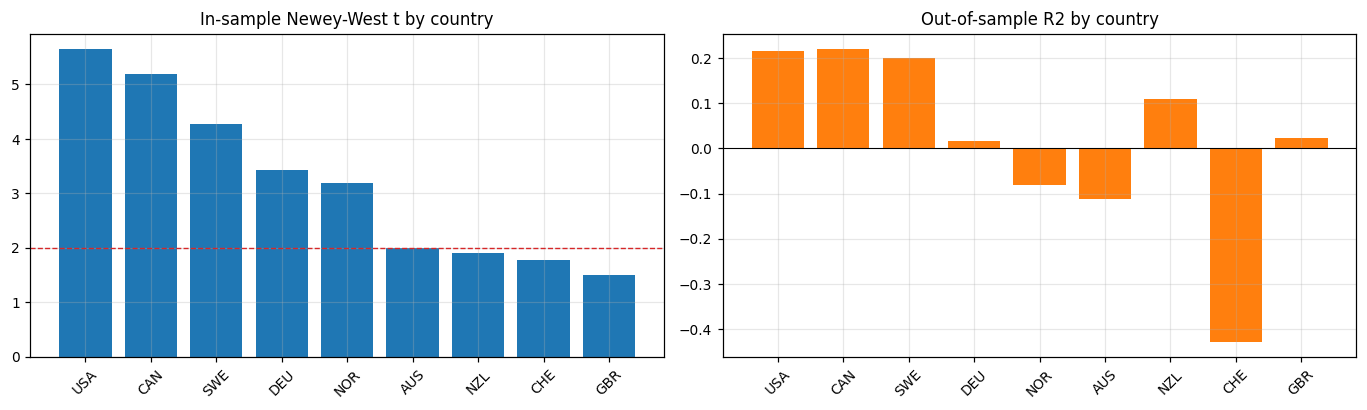


HONEST NOTES: rx uses the duration approximation on the 10y level (no full foreign curves on FRED);
OECD series are revised and country spans differ; this is the SAME formulation pre-specified on US data,
so cross-country replication here is genuine new evidence, not another formulation (no extra testing discount).


In [3]:
# ===== The affine-anchor test, pre-specified, replicated country by country =====
MINW=120; H=12
def vas_B(tau,k): k=max(k,1e-4); return (1-np.exp(-k*tau))/k
def vas_yield(tau,rr,k,th,s):
    k=max(k,1e-4); B=vas_B(tau,k)
    lnA=(th-s*s/(2*k*k))*(B-tau)-s*s*B*B/(4*k); return (-lnA+B*rr)/tau
def ols_nw(yv,Xc,L):
    X=np.column_stack([np.ones(len(yv))]+[c for c in Xc]); b=np.linalg.lstsq(X,yv,rcond=None)[0]
    e=yv-X@b; XtX=np.linalg.inv(X.T@X); Xe=X*e[:,None]; S=Xe.T@Xe
    for l in range(1,L+1):
        w=1-l/(L+1); G=Xe[l:].T@Xe[:-l]; S=S+w*(G+G.T)
    V=XtX@S@XtX; return b,np.sqrt(np.diag(V)),1-(e@e)/(((yv-yv.mean())**2).sum())
def oos_r2(P,yv,H,minobs=MINW):
    P=P.reshape(-1,1) if P.ndim==1 else P; num=den=0.0; nf=0
    for t in range(minobs+H,len(yv)):
        if not np.isfinite(yv[t]) or not np.isfinite(P[t]).all(): continue
        s_=np.arange(0,t-H+1); m=np.isfinite(yv[s_])&np.isfinite(P[s_]).all(1)
        if m.sum()<minobs: continue
        Xtr=np.column_stack([np.ones(m.sum()),P[s_][m]]); btr=np.linalg.lstsq(Xtr,yv[s_][m],rcond=None)[0]
        num+=(yv[t]-(btr[0]+P[t]@btr[1:]))**2; den+=(yv[t]-yv[s_][m].mean())**2; nf+=1
    return (1-num/den if den>0 else np.nan),nf
def cw_t(P,yv,H,minobs=MINW,nwlag=12):
    from statistics import NormalDist
    P=P.reshape(-1,1) if P.ndim==1 else P; fts=[]
    for t in range(minobs+H,len(yv)):
        if not np.isfinite(yv[t]) or not np.isfinite(P[t]).all(): continue
        s_=np.arange(0,t-H+1); m=np.isfinite(yv[s_])&np.isfinite(P[s_]).all(1)
        if m.sum()<minobs: continue
        yb=yv[s_][m].mean()
        Xtr=np.column_stack([np.ones(m.sum()),P[s_][m]]); btr=np.linalg.lstsq(Xtr,yv[s_][m],rcond=None)[0]
        ym=btr[0]+P[t]@btr[1:]; eb=yv[t]-yb; em=yv[t]-ym
        fts.append(eb*eb-(em*em-(yb-ym)**2))
    f=np.array(fts,float); n=len(f)
    if n<24: return np.nan,n
    u=f-f.mean(); S=np.sum(u*u)/n
    for l in range(1,nwlag+1):
        w=1-l/(nwlag+1); S+=2*w*np.sum(u[l:]*u[:-l])/n
    return f.mean()/np.sqrt(S/n),n

def run_country(df):
    idx=df.index; n=len(df)
    r=df["r3m"].to_numpy(); y10=df["y10"].to_numpy()
    pi=df["cpi"].pct_change(12).ewm(halflife=36).mean().bfill().to_numpy()
    rst=pd.Series(r-pi,index=idx).ewm(halflife=120).mean().bfill().to_numpy()
    anc=rst+pi
    kt=np.full(n,np.nan); st=np.full(n,np.nan)
    for t in range(MINW,n):
        g=anc[:t]-r[:t]; d=r[1:t+1]-r[:t]
        X=np.column_stack([np.ones(t),g]); a0,sl=np.linalg.lstsq(X,d,rcond=None)[0]
        kt[t]=float(np.clip(sl*12,1e-4,20)); st[t]=float(np.std(d-(a0+sl*g)))*np.sqrt(12)
    TP=np.full(n,np.nan)
    for t in range(MINW,n): TP[t]=y10[t]-vas_yield(10.0,r[t],kt[t],anc[t],st[t])
    D=(1-(1+np.maximum(y10,1e-4))**-10)/np.maximum(y10,1e-4)
    rx=np.full(n,np.nan)
    for t in range(n-H): rx[t]=y10[t]-D[t]*(y10[t+H]-y10[t])-r[t]
    f=np.isfinite(TP)&np.isfinite(rx)
    if f.sum()<MINW+24: return None
    z=(TP-np.nanmean(TP[f]))/np.nanstd(TP[f])
    b,se,r2=ols_nw(rx[f],[z[f]],H)
    o,_=oos_r2(TP,rx,H); tcw,ncw=cw_t(TP,rx,H)
    return {"beta_perSD":b[1],"NW_t":b[1]/se[1],"IS_R2":r2,"OOS_R2":o,"CW_t":tcw,"n_eval":ncw,
            "kappa_HW":kt[~np.isnan(kt)][-1]}

RES={}
for c,df in PD.items():
    out=run_country(df)
    if out is not None: RES[c]=out
tab=pd.DataFrame(RES).T.sort_values("NW_t",ascending=False)
print("PER-COUNTRY REPLICATION of the affine-anchor test (same pre-specified pipeline everywhere)\n")
print(tab.to_string())
bet=tab["beta_perSD"].to_numpy(); N=len(bet)
mg_t=bet.mean()/(bet.std(ddof=1)/np.sqrt(N))
print(f"\nMEAN-GROUP estimate (Pesaran-style): beta = {bet.mean()*100:+.2f}%/SD | t = {mg_t:.2f} (cross-country dispersion, N={N})")
print(f"Sign replication : {(bet>0).sum()}/{N} positive betas | NW t>2: {(tab['NW_t']>2).sum()}/{N} | NW t>1.65: {(tab['NW_t']>1.65).sum()}/{N}")
print(f"Out-of-sample    : OOS_R2>0 in {(tab['OOS_R2']>0).sum()}/{N} countries | CW_t>1.282 (10%) in {(tab['CW_t']>1.282).sum()}/{N}")
fig,ax=plt.subplots(1,2,figsize=(12.5,3.8))
ax[0].bar(tab.index,tab["NW_t"]); ax[0].axhline(2,color="C3",ls="--",lw=.9); ax[0].axhline(0,color="k",lw=.5)
ax[0].set_title("In-sample Newey-West t by country"); ax[0].tick_params(axis='x',rotation=45)
ax[1].bar(tab.index,tab["OOS_R2"],color="C1"); ax[1].axhline(0,color="k",lw=.7)
ax[1].set_title("Out-of-sample R2 by country"); ax[1].tick_params(axis='x',rotation=45)
plt.tight_layout(); plt.show()
print("\nHONEST NOTES: rx uses the duration approximation on the 10y level (no full foreign curves on FRED);")
print("OECD series are revised and country spans differ; this is the SAME formulation pre-specified on US data,")
print("so cross-country replication here is genuine new evidence, not another formulation (no extra testing discount).")


## Caveats that stay attached to any headline

The duration-approximated $rx$ ignores roll-down and curve shape; OECD series are revised
(no true real-time vintages) and spans differ by country; short samples bias $\hat\kappa$ up
everywhere; cross-country results are **not independent** draws (global rate cycles
correlate — the mean-group t overstates independence, so read the sign-replication count as
the primary statistic); and JPN spends decades at the ZLB where the Vasicek anchor is least
at home. If the replication holds *despite* all of that, it is meaningful; if it holds only
in a subset, the subset — and the failures — are the finding.